# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#8b4513;">A predictive system to detect presence and severity of cardiovascular disease (CVD) using Binary and Multi-classification in Machine Learning Fusion approach </p>


***This is the first Code for binary classification fusion model-1 (SVM+LR) using weighted score fusion***

***Group-1: Akash, Masud, Soumitra,Noyon***

In [29]:
import pandas as pd  # pandas for data handling and DataFrame operations
from sklearn.model_selection import train_test_split  # split dataset into train and test sets
from sklearn.preprocessing import MinMaxScaler,StandardScaler  # scalers for feature normalization
from matplotlib import pyplot as plt  # plotting library for visualizations
import numpy  # numpy for numerical operations (alias imported below as np)
import numpy as np  # numpy as np for array operations and numerical functions
from sklearn.metrics import classification_report  # classification report utility
import sklearn.metrics as metrics  # metrics module for accuracy, roc, confusion matrix

In [30]:
data = pd.read_csv('binary classification.csv')  # load dataset from CSV into a DataFrame named 'data'
data.head(10)  # display first 10 rows to inspect columns and sample values

,age,chest pain,restBP,cholesterol,max HR,exerc ind ang,ST by exercise,slope,major vessels colored,thal,gender,fasting blood sugar,rest ECG,target
0,63,3,145,233,150,0,2.3,0,0,0,1,1,1,0
1,67,0,160,286,108,1,1.5,1,3,1,1,0,1,1
2,67,0,120,229,129,1,2.6,1,2,2,1,0,1,1
3,37,2,130,250,187,0,3.5,0,0,1,1,0,2,0
4,41,1,130,204,172,0,1.4,2,0,1,0,0,1,0
5,56,1,120,236,178,0,0.8,2,0,1,1,0,2,0
6,62,0,140,268,160,0,3.6,0,2,1,0,0,1,1
7,57,0,120,354,163,1,0.6,2,0,1,0,0,2,0
8,63,0,130,254,147,0,1.4,1,1,2,1,0,1,1
9,53,0,140,203,155,1,3.1,0,0,2,1,1,1,1


In [31]:
data.shape  # get the number of rows and columns in the DataFrame

(303, 14)

In [32]:
data.info()  # get summary of DataFrame including data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    303 non-null    int64  
 1   chest pain             303 non-null    int64  
 2   restBP                 303 non-null    int64  
 3   cholesterol            303 non-null    int64  
 4   max HR                 303 non-null    int64  
 5   exerc ind ang          303 non-null    int64  
 6   ST by exercise         303 non-null    float64
 7   slope                  303 non-null    int64  
 8   major vessels colored  303 non-null    int64  
 9   thal                   303 non-null    int64  
 10  gender                 303 non-null    int64  
 11  fasting blood sugar    303 non-null    int64  
 12  rest ECG               303 non-null    int64  
 13  target                 303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [33]:
data.isnull().sum()  # get the count of null values in each column of the DataFrame

age                      0
chest pain               0
restBP                   0
cholesterol              0
max HR                   0
exerc ind ang            0
ST by exercise           0
slope                    0
major vessels colored    0
thal                     0
gender                   0
fasting blood sugar      0
rest ECG                 0
target                   0
dtype: int64

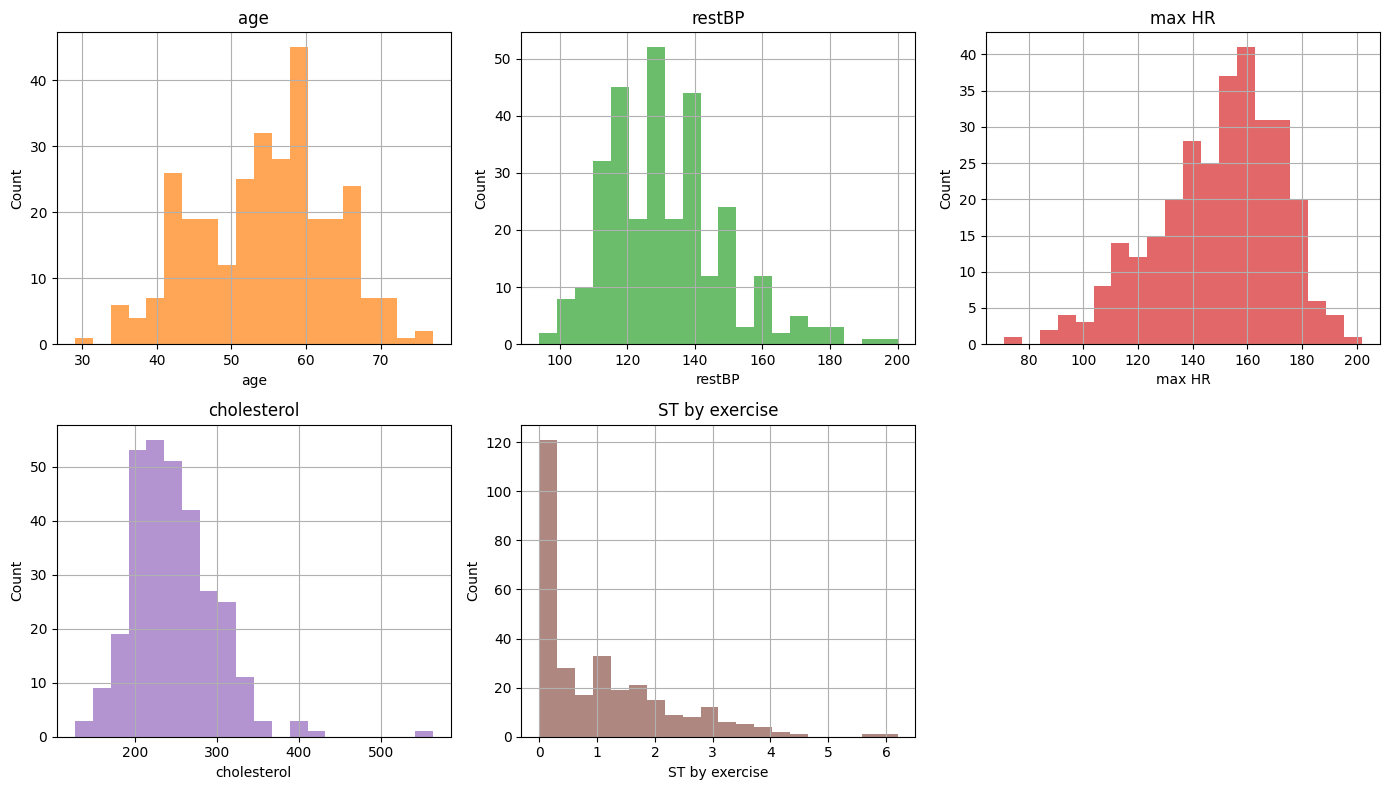

In [34]:
# Histogram distributions for selected features: Age, restBP, Max HR, cholesterol, ST by exercise
import matplotlib.pyplot as plt
# list of feature names to look for (case-insensitive, partial matching)
requested = ['Age', 'restBP', 'Max HR', 'cholesterol', 'ST by exercise']
cols = []
for f in requested:
    matches = [c for c in data.columns if f.lower() in c.lower()]
    if matches:
        cols.append(matches[0])
    else:
        # try matching by individual words if full phrase not found
        for part in f.split():
            m = [c for c in data.columns if part.lower() in c.lower()]
            if m:
                cols.append(m[0])
                break
# remove duplicates while preserving order
cols = list(dict.fromkeys(cols))
if not cols:
    print('No matching columns found for requested features. Available columns:', list(data.columns))
else:
    plt.figure(figsize=(14, 8))
    n = len(cols)
    cols_per_row = 3
    rows = (n + cols_per_row - 1) // cols_per_row
    for i, c in enumerate(cols, 1):
        ax = plt.subplot(rows, cols_per_row, i)
        data[c].dropna().hist(bins=20, color=f'C{i}', alpha=0.7)
        ax.set_title(c)
        ax.set_xlabel(c)
        ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
    

In [35]:
x = data.iloc[:,0:13].values  # select first 13 columns as feature matrix X (all rows)
y = data.iloc[:,13].values  # select 14th column as target vector y (labels)

In [36]:
#for 80:20 ratio  # example alternative split commented out
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True)  # 80/20 split

#for 70:30 ratio  # using 70% train, 30% test
# X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True)  # create train/test sets

#StandardScaler for normalization for some algortihms
sc = StandardScaler()  # standard scaler (zero mean, unit variance)

#min-max scaler for normalization for some algortihms
scaler = MinMaxScaler(feature_range=(0,1))  # scale features to range [0,1]

In [37]:
# code for SVM  # build and evaluate a Support Vector Machine classifier

from sklearn.svm import SVC  # import SVM classifier
model4 = SVC(probability=True,C=1,gamma=.01)  # initialize SVM with probability estimates and hyperparameters

scaled_X_train_svm=sc.fit_transform(X_train)  # scale training features using StandardScaler
scaled_X_test_svm=sc.transform(X_test)  # scale test features using fitted scaler
 
# features for SVM
scaled_X_train_svm1 = scaled_X_train_svm[:,0:13]  # select relevant feature columns for SVM
scaled_X_test_svm1 = scaled_X_test_svm[:,0:13]  # select same feature columns for test set

model4.fit(scaled_X_train_svm1,y_train)  # train the SVM on scaled training features
            


SVC(C=1, gamma=0.01, probability=True)

In [38]:
rounded_predictions1 = model4.predict(scaled_X_test_svm1)  # predicted class labels for test set
predictions1 =model4.predict_proba(scaled_X_test_svm1)  # predicted class probabilities for test set
y_pred4 = rounded_predictions1  # assign predicted labels to variable used later

import sklearn.metrics as metrics  # import metrics module (re-import safe)
scores4=metrics.accuracy_score(y_test,y_pred4)  # compute accuracy of SVM predictions
print("SVM",scores4)  # print SVM accuracy

SVM 0.7868852459016393


In [39]:
import sklearn.metrics as metrics  # import metrics module (re-import safe)
scores4=metrics.accuracy_score(y_test,y_pred4)  # compute accuracy of SVM predictions
print("Accuracy of SVM = ",scores4)  # print SVM accuracy
print(metrics.confusion_matrix(y_test,y_pred4))  # print confusion matrix for SVM predictions
print(metrics.classification_report(y_test,y_pred4))  # print precision/recall/f1 and support for each class

Accuracy of SVM =  0.7868852459016393
[[28  5]
 [ 8 20]]
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        33
           1       0.80      0.71      0.75        28

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



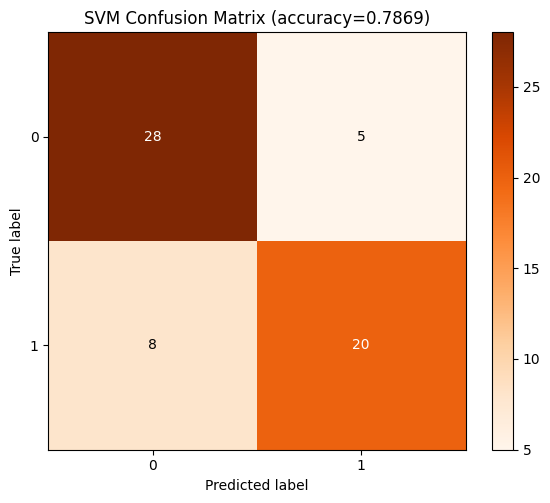

In [40]:
# Plot confusion matrix heatmap for the trained SVM model
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred4)  # true vs predicted for SVM
acc = accuracy_score(y_test, y_pred4)
labels = np.unique(np.concatenate((y_test, y_pred4)))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(labels)), yticks=np.arange(len(labels)),
       xticklabels=labels, yticklabels=labels,
       ylabel='True label', xlabel='Predicted label',
       title=f'SVM Confusion Matrix (accuracy={acc:.4f})')
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

In [41]:
fpr4, tpr4, threshold = metrics.roc_curve(y_test, y_pred4)  # compute ROC curve points for SVM
roc_auc4 = metrics.auc(fpr4, tpr4)  # compute AUC for SVM ROC
print("roc_auc_SVM",roc_auc4)  # print AUC value

roc_auc_SVM 0.7813852813852814


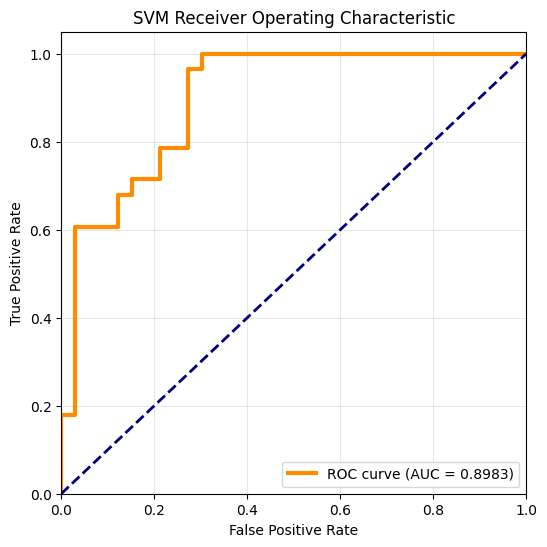

In [42]:
# Plot ROC curve and display AUC for the trained SVM model
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# prefer probability for positive class if available
try:
    y_score = predictions1[:, 1]  # probability of positive class
except Exception:
    y_score = predictions1  # fallback if already 1-d
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.figure(figsize=(6, 6))
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=3,
         label=f'ROC curve (AUC = {roc_auc_svm:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [43]:
#code for LR  # build and evaluate a Logistic Regression classifier

from sklearn.linear_model import LogisticRegression  # import logistic regression
model5 =LogisticRegression(C=1)  # initialize LR with regularization strength C=1
model5.fit(X_train,y_train)  # train LR on (unscaled) training data
rounded_predictions2 = model5.predict(X_test)  # predicted class labels for LR on test set
predictions2 =model5.predict_proba(X_test)  # predicted class probabilities for LR
y_pred5= rounded_predictions2  # assign predicted labels to variable used later

c:\Users\USER\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
import sklearn.metrics as metrics  # import metrics module (re-import safe)
scores5=metrics.accuracy_score(y_test,y_pred5)  # compute LR accuracy
print("Accuracy of LR = ",scores5)  # print LR accuracy

print(metrics.confusion_matrix(y_test,y_pred5))  # print confusion matrix for LR
print(metrics.classification_report(y_test,y_pred5))  # print classification report for LR

        
fpr5, tpr5, threshold = metrics.roc_curve(y_test, y_pred5)  # compute ROC curve points for LR
roc_auc5 = metrics.auc(fpr5, tpr5)  # compute AUC for LR
print("roc_auc_LR",roc_auc5)  # print LR AUC

Accuracy of LR =  0.8360655737704918
[[28  5]
 [ 5 23]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        33
           1       0.82      0.82      0.82        28

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61

roc_auc_LR 0.8349567099567099


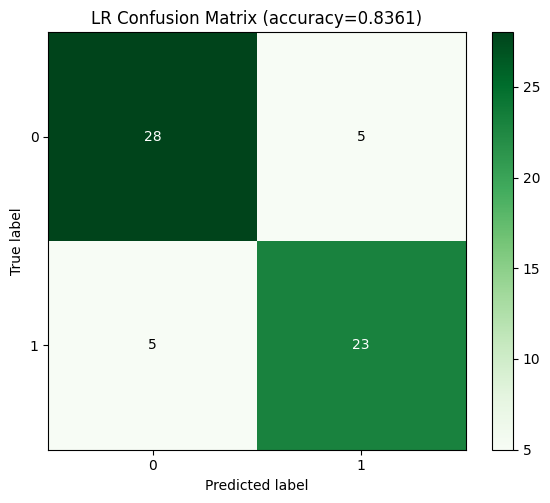

In [45]:
# Plot confusion matrix heatmap for the trained Logistic Regression model
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred5)  # true vs predicted for LR
acc = accuracy_score(y_test, y_pred5)
labels = np.unique(np.concatenate((y_test, y_pred5)))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(labels)), yticks=np.arange(len(labels)),
       xticklabels=labels, yticklabels=labels,
       ylabel='True label', xlabel='Predicted label',
       title=f'LR Confusion Matrix (accuracy={acc:.4f})')
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

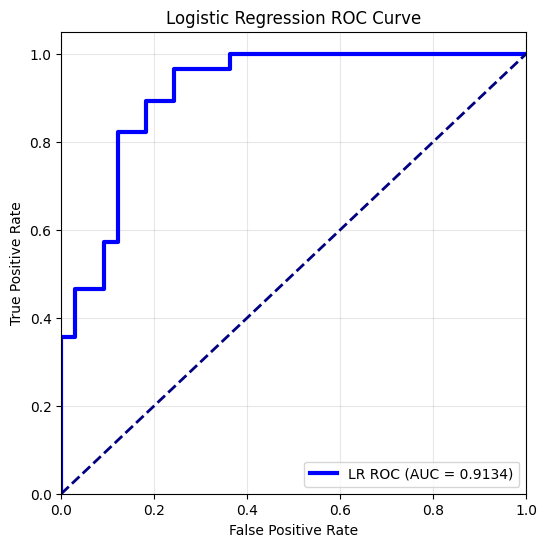

In [46]:
# ROC curve for Logistic Regression (plotted after LR training)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# Use predicted probabilities for the positive class from Logistic Regression
try:
    y_score_lr = predictions2[:, 1]  # probability of positive class
except Exception:
    # If predictions2 is 1-D or unavailable, fallback to predicted labels (less informative)
    y_score_lr = predictions2

# Compute ROC curve and AUC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=3, label=f'LR ROC (AUC = {roc_auc_lr:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [47]:
#selecting the best value for p and q(p & q represents the weights w1 & w2)
p=1  # start weight p at 1
#q=1-p
for i in range (19):  # iterate to test different weight combinations
    p=p-.05  # decrement p by 0.05 each iteration
    q=1-p  # compute complementary weight q

  
    mixed=predictions1[:,1]*p+predictions2[:,1]*q  # weighted sum of positive-class probabilities from two models
    rounded_mixed=mixed  # initialize rounded_mixed as same shape (will overwrite values below)
    for i in range(len(y_test)):  # convert probabilities to binary class labels using 0.5 threshold
        if mixed[i]>.5:
            rounded_mixed[i]=1
        else:
            rounded_mixed[i]=0

    score=metrics.accuracy_score(rounded_mixed,y_test)  # compute accuracy for this weight combo
    print("  mixed  p  q","%.4f" %score, "%.2f" %p,"%.2f" %q)  # display accuracy and weights

  mixed  p  q 0.7541 0.95 0.05
  mixed  p  q 0.7541 0.90 0.10
  mixed  p  q 0.7705 0.85 0.15
  mixed  p  q 0.7869 0.80 0.20
  mixed  p  q 0.8033 0.75 0.25
  mixed  p  q 0.8033 0.70 0.30
  mixed  p  q 0.8033 0.65 0.35
  mixed  p  q 0.8033 0.60 0.40
  mixed  p  q 0.8197 0.55 0.45
  mixed  p  q 0.8361 0.50 0.50
  mixed  p  q 0.8361 0.45 0.55
  mixed  p  q 0.8361 0.40 0.60
  mixed  p  q 0.8361 0.35 0.65
  mixed  p  q 0.8361 0.30 0.70
  mixed  p  q 0.8361 0.25 0.75
  mixed  p  q 0.8361 0.20 0.80
  mixed  p  q 0.8361 0.15 0.85
  mixed  p  q 0.8361 0.10 0.90
  mixed  p  q 0.8361 0.05 0.95


In [48]:
#after selecting the value of p and q which gives the highest accuracy. This value differs for different algorithms.
p=.85  # chosen weight for model4 (SVM)
q=1-p  # complementary weight for model5 (LR)

mixed=predictions1[:,1]*p+predictions2[:,1]*q  # compute weighted probability mix for positive class
for i in range(len(y_test)):  # convert mixed probabilities to binary predictions
    if mixed[i]>=.5:
        rounded_mixed[i]=1
    else:
         rounded_mixed[i]=0
            
score=metrics.accuracy_score(rounded_mixed,y_test)  # compute final accuracy for chosen weights
print("Ensemble Accuracy = ",score)  # print fused-model accuracy

print(metrics.confusion_matrix(y_test,rounded_mixed))  # print confusion matrix for fused predictions
print(metrics.classification_report(y_test,rounded_mixed))  # print classification report for fused predictions

fpr, tpr, threshold = metrics.roc_curve(rounded_mixed,y_test)  # compute ROC curve for fused predictions
roc_auc = metrics.auc(fpr, tpr)  # compute AUC for fused ROC
print("roc_auc_tot",roc_auc)  # print overall ROC AUC for fused model

Ensemble Accuracy =  0.7704918032786885
[[26  7]
 [ 7 21]]
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        33
           1       0.75      0.75      0.75        28

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61

roc_auc_tot 0.7689393939393939


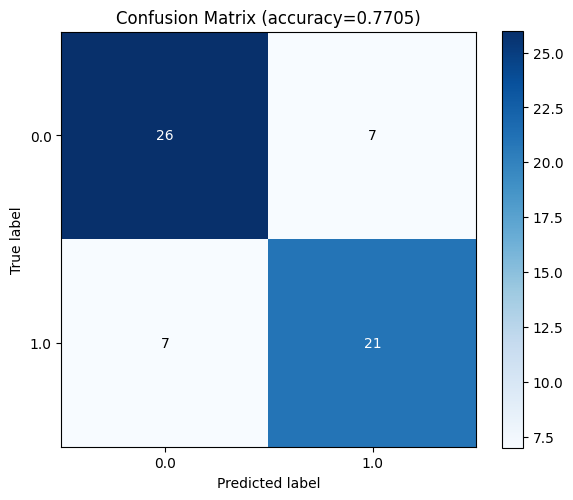

In [49]:
# Confusion matrix heatmap for the fused predictions (visual)
from sklearn.metrics import confusion_matrix, accuracy_score  # compute confusion matrix and accuracy
import matplotlib.pyplot as plt  # plotting library
import numpy as np  # numerical operations

# compute confusion matrix between true labels and fused rounded predictions
cm = confusion_matrix(y_test, rounded_mixed)  # rows = true labels, cols = predicted labels
acc = accuracy_score(y_test, rounded_mixed)  # overall accuracy for display

# determine label set for axis ticks
labels = np.unique(np.concatenate((y_test, rounded_mixed)))  # unique class labels present

# create figure and show heatmap
fig, ax = plt.subplots(figsize=(6, 5))  # create a figure to plot
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)  # display confusion matrix as image
ax.figure.colorbar(im, ax=ax)  # add colorbar to show scale

# set tick labels and axis labels
ax.set(xticks=np.arange(len(labels)), yticks=np.arange(len(labels)),
       xticklabels=labels, yticklabels=labels,
       ylabel='True label', xlabel='Predicted label',
       title=f'Confusion Matrix (accuracy={acc:.4f})')  # set axis labels and title including accuracy

# annotate each cell with the numeric count
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')  # text color contrasts with cell color

plt.tight_layout()  # adjust layout to fit labels
plt.show()  # render the plot

In [50]:
# Compute and print confusion-matrix metrics (textual)
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support  # metric utilities
import numpy as np  # numerical operations

# compute confusion matrix again to ensure availability
cm = confusion_matrix(y_test, rounded_mixed)  # rows are true labels, cols are predicted labels
print('Confusion Matrix (rows=true labels, cols=predicted labels):')
print(cm)  # print raw counts

# print classification report with precision, recall, f1-score per class
print('\nClassification Report:')
print(classification_report(y_test, rounded_mixed))  # detailed per-class metrics

# compute weighted precision/recall/f1 for a summary
precision, recall, f1, _ = precision_recall_fscore_support(y_test, rounded_mixed, average='weighted')
print(f'Weighted Precision: {precision:.4f}, Weighted Recall: {recall:.4f}, Weighted F1: {f1:.4f}')  # print weighted metrics

# Optionally compute normalized confusion matrix for review
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize rows to sum to 1
print('\nNormalized Confusion Matrix (rows sum to 1):')
print(np.round(cm_normalized, 3))  # print rounded normalized confusion matrix

Confusion Matrix (rows=true labels, cols=predicted labels):
[[26  7]
 [ 7 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        33
           1       0.75      0.75      0.75        28

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61

Weighted Precision: 0.7705, Weighted Recall: 0.7705, Weighted F1: 0.7705

Normalized Confusion Matrix (rows sum to 1):
[[0.788 0.212]
 [0.25  0.75 ]]


In [51]:
mixed.shape  # show the shape of mixed probability array (rows = number of test samples)

(61,)

In [52]:
#same code for the plot of the fusion model and the models we used in fusion.


from sklearn.preprocessing import label_binarize  # utility to convert labels to one-vs-all binary format
y_test_h = label_binarize(y_test, classes=[0, 1, 2, 3, 4])  # one-hot encode true labels for multi-class ROC


y_score1 = label_binarize(y_pred4, classes=[0, 1, 2, 3, 4])  # one-hot encode predicted labels/scores for SVM
from sklearn.metrics import roc_curve, auc  # functions to compute ROC and AUC
from numpy import interp  # interpolation function for merging ROC curves
from itertools import cycle  # utility to cycle through colors for plotting
n_classes=5  # number of classes
lw=3  # line width for plots
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_h[:, i], y_score1[:, i])  # compute fpr and tpr for each class
    roc_auc[i] = auc(fpr[i], tpr[i])  # compute AUC per class

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_h.ravel(), y_score1.ravel())  # micro-average across classes
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])  # micro-average AUC


# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))  # union of all fpr values

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)  # initialize mean tpr accumulator
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # interpolate each class's tpr at points in all_fpr

# Finally average it and compute AUC
mean_tpr /= n_classes  # average interpolated tprs across classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])  # macro-average AUC

c:\Users\USER\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


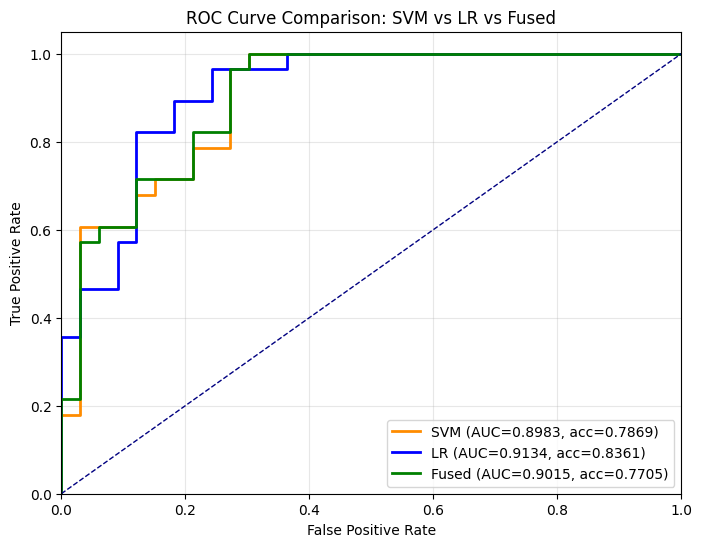

AUCs -> SVM: 0.8983, LR: 0.9134, Fused: 0.9015


In [53]:
# Combined ROC-AUC curve for SVM, Logistic Regression and Fused ensemble
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtain probability scores for the positive class where available
try:
    y_score_svm = predictions1[:, 1]
except Exception:
    y_score_svm = predictions1
try:
    y_score_lr = predictions2[:, 1]
except Exception:
    y_score_lr = predictions2
# 'mixed' contains fused positive-class probabilities computed earlier
y_score_fused = mixed

# Compute ROC curves and AUCs
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
fpr_fused, tpr_fused, _ = roc_curve(y_test, y_score_fused)
auc_svm = auc(fpr_svm, tpr_svm)
auc_lr = auc(fpr_lr, tpr_lr)
auc_fused = auc(fpr_fused, tpr_fused)

# Plotting the curves together
plt.figure(figsize=(8,6))
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label=f'SVM (AUC={auc_svm:.4f}, acc={scores4:.4f})')
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'LR (AUC={auc_lr:.4f}, acc={scores5:.4f})')
plt.plot(fpr_fused, tpr_fused, color='green', lw=2, label=f'Fused (AUC={auc_fused:.4f}, acc={score:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: SVM vs LR vs Fused')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Print numeric AUCs
print(f'AUCs -> SVM: {auc_svm:.4f}, LR: {auc_lr:.4f}, Fused: {auc_fused:.4f}')